In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, Subset, random_split, ConcatDataset
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os
import math
import gc

@dataclass
class hyper_parameters:
    y_dim: int = 3
    u_dim: int = 32
    z_dim: int = 512
    num_layers: int = 4
    
class cICNN_layer(nn.Module):
    def __init__(self, config: hyper_parameters):
        super().__init__()
        ''' strain stream use "e", latent stream use "z" or "m" '''
        # U-Path (Non-Convex Latent Space Input)
        self.W_uu = nn.Linear(config.u_dim, config.u_dim, bias=True)
        
        # Z-Path (Convex Strain Input)
        # latent space contribution
        self.W_zu = nn.Linear(config.u_dim, config.z_dim, bias=True)
        self.W_z  = nn.Linear(config.z_dim, config.z_dim, bias=False) 
        
        target_post_softplus = 1.0 / config.z_dim
        init_mean = math.log(math.exp(target_post_softplus) - 1.0) 
        
        nn.init.normal_(self.W_z.weight, mean=init_mean, std=0.01)
        # nn.init.normal_(self.W_z.weight, mean=0, std=0.1)
        
        # strain contribution
        self.W_u  = nn.Linear(config.u_dim, config.z_dim, bias=True) 
        
        # cross attention contribution
        self.W_yu = nn.Linear(config.u_dim, config.y_dim, bias=True)
        self.W_y  = nn.Linear(config.y_dim, config.z_dim, bias=False) 
        self.W_y0 = nn.Linear(config.y_dim, config.z_dim, bias=False) 
        self.W_y1 = nn.Linear(config.y_dim, config.z_dim, bias=False) 
        
    def forward(self, inputs):
        y, u_i, z_i = inputs
        
        # NON-CONVEX UPDATE: u_{i+1}
        u_next = F.silu(self.W_uu(u_i))
        
        # CONVEX UPDATE: z_{i+1}
        # Term 1: Wz.(z*(Wzu.u+b)+) #latent path 
        zu_p = z_i * F.softplus(self.W_zu(u_i)) 
        term1 = F.linear(zu_p, F.softplus(self.W_z.weight)) 
        # term1 =  self.W_z(z_i * self.W_zu(u_i))
        # Term 2: Wy.(y*(Wyu.u+b)+) #cross attention path
        input_gate = self.W_yu(u_i) 
        yu = y * input_gate 
        term2 = self.W_y(yu)
        
        # Term 3: strain path 
        term3 = self.W_u(u_i)
        
        term4 = self.W_y0(y)
        
        term5 = self.W_y1(y*y)
        
        z_next = F.softplus(term1 + term2 + term3 + term4 + term5)
        return (y, u_next, z_next)
        
class cICNN_NN(nn.Module):
    def __init__(self, config: hyper_parameters):
        super().__init__()
        
        # 1. Initial Processing of Latent Geometry (Z from your VAE)
        self.u_init = nn.Sequential(
            nn.Linear(config.u_dim, config.u_dim),
            nn.SiLU()
        )
        
        # Layer 0 
        # z_1 = Softplus(W_y y + W_u u_0 + b)
        self.layer_0_y = nn.Linear(config.y_dim, config.z_dim, bias=False)
        self.layer_0_u = nn.Linear(config.u_dim, config.z_dim, bias=True)
        
        layers = []
        for _ in range(config.num_layers):
            layers.append(cICNN_layer(config))
        
        self.hidden_layers = nn.Sequential(*layers)
        self.final_layer = nn.Linear(config.z_dim, 1, bias=True)
        
        target_post_softplus = 1.0 / config.z_dim
        init_mean = math.log(math.exp(target_post_softplus) - 1.0) 
        
        nn.init.normal_(self.final_layer.weight, mean=init_mean, std=0.01)

    def _forward_raw(self, y, u):
        while u.dim() < y.dim(): u = u.unsqueeze(1)
        u_0 = self.u_init(u)
        z_1 = F.softplus(self.layer_0_y(y) + self.layer_0_u(u_0))
        
        _, _, z_out = self.hidden_layers((y, u_0, z_1))
        
        W_pred = F.linear(z_out, F.softplus(self.final_layer.weight), self.final_layer.bias)
        
        return W_pred
    
    def forward(self, strain, geometry):
        """ This enforce 0 energy,stress at 0 strain """
        if not strain.requires_grad:
            strain.requires_grad_(True)
            
        W_e = self._forward_raw(strain, geometry)
        strain_zero = torch.zeros_like(strain, requires_grad=True)
        W_zero = self._forward_raw(strain_zero, geometry)
        
        S_zero = torch.autograd.grad(W_zero, strain_zero, torch.ones_like(W_zero), create_graph=True)[0]
        linear_offset = torch.sum(S_zero * strain, dim=-1, keepdim=True)
        W_phys = W_e - W_zero - linear_offset
        
        return W_phys

    def _forward(self, y, u):
        while u.dim() < y.dim(): u = u.unsqueeze(1)
        u_0 = self.u_init(u)
        z_1 = F.softplus(self.layer_0_y(y) + self.layer_0_u(u_0))
        
        _, _, z_out = self.hidden_layers((y, u_0, z_1))
        
        W_pred = F.linear(z_out, F.softplus(self.final_layer.weight), self.final_layer.bias)
        
        return W_pred
    
class VAE_encoder(nn.Module):
    def __init__(self, config: hyper_parameters):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.01),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.01),
            nn.Flatten()
        )
        self.z_mu     = nn.Linear(4096, config.u_dim)
        self.z_logvar = nn.Linear(4096, config.u_dim)

    def reparameterize(self, mu, logvar):
        """ sampling the VAE latent space """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.encoder(x)
        mu     = self.z_mu(hidden)
        logvar = self.z_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

class VAE_decoder(nn.Module):
    def __init__(self, config: hyper_parameters):
        super().__init__()
        self.fc_decode = nn.Linear(config.u_dim, 4096)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, z):
        hidden = self.fc_decode(z)
        hidden = hidden.view(-1, 256, 4, 4)
        reconstruction = self.decoder(hidden)
        return reconstruction

class surrogateNN(nn.Module):
    def __init__(self, config: hyper_parameters):
        super().__init__()
        self.encoder = VAE_encoder(config)
        self.decoder = VAE_decoder(config)
        self.energy_predictor = cICNN_NN(config)

    def forward(self, geometry, strains):
        z, mu, logvar = self.encoder(geometry)
        reconstruction = self.decoder(z)
        W_phys = self.energy_predictor(strains, mu)
        
        return W_phys, reconstruction, mu, logvar

In [20]:
# class VRAMStorage:
#     """Loads the HDF5 data into GPU VRAM exactly once, physically excluding NaNs/Infs."""
#     def __init__(self, h5_path, device='cuda'):
#         print(f"Bypassing I/O: Loading H5 into GPU VRAM and filtering...")
#         bad_indices = []
        
#         with h5py.File(h5_path, 'r') as f:
#             total_len = len(f['topologies'])
#             print(f"Found {total_len} total samples. Processing in chunks...")
            
#             # Lists to hold the clean chunks before final assembly
#             topo_list = []
#             energy_list = []
#             strain_list = []
#             stress_list = []
            
#             chunk_size = 5000 # Smaller chunks to ensure 4GB System RAM isn't hit
            
#             for i in range(0, total_len, chunk_size):
#                 end = min(i + chunk_size, total_len)
                
#                 # 1. Load to CPU temp -> Push to VRAM as temporary chunk tensors
#                 chunk_topo = torch.from_numpy(f['topologies'][i:end]).view(-1, 1, 64, 64).float().to(device)
#                 chunk_energy = torch.from_numpy(f['strain_energy'][i:end]).float().to(device) 
#                 chunk_strain = torch.from_numpy(f['strain'][i:end]).float().to(device)
#                 chunk_stress = torch.from_numpy(f['stress'][i:end]).float().to(device) 
                
#                 # 2. Identify corrupted entries in this specific chunk
#                 nan_mask = torch.isnan(chunk_energy).any(dim=(1,2)) | torch.isnan(chunk_stress).any(dim=(1,2,3,4))
#                 inf_mask = torch.isinf(chunk_energy).any(dim=(1,2)) | torch.isinf(chunk_stress).any(dim=(1,2,3,4))
                
#                 invalid_mask = nan_mask | inf_mask
#                 valid_mask = ~invalid_mask  # Invert to get the clean data
                
#                 num_invalid = invalid_mask.sum().item()
                
#                 # 3. If corruption is found, log it and slice it out
#                 if num_invalid > 0:
#                     corrupted_in_chunk = invalid_mask.nonzero(as_tuple=True)[0]
#                     bad_indices.extend((corrupted_in_chunk + i).tolist())
                    
#                     # Physically filter the chunk tensors (keeps only valid rows)
#                     chunk_topo = chunk_topo[valid_mask]
#                     chunk_energy = chunk_energy[valid_mask]
#                     chunk_strain = chunk_strain[valid_mask]
#                     chunk_stress = chunk_stress[valid_mask]
                
#                 # 4. Append the clean chunks to our lists
#                 topo_list.append(chunk_topo)
#                 energy_list.append(chunk_energy)
#                 strain_list.append(chunk_strain)
#                 stress_list.append(chunk_stress)
                
#                 if (i // chunk_size) % 2 == 0: 
#                     print(f"Progress: {end}/{total_len} processed.")
        
#         print(f"Concatenating filtered chunks into contiguous VRAM blocks...")
#         # 5. Assemble the final, clean dataset directly in VRAM
#         self.topologies = torch.cat(topo_list, dim=0)
#         self.energies = torch.cat(energy_list, dim=0)
#         self.strains_max = torch.cat(strain_list, dim=0)
#         self.stresses_max = torch.cat(stress_list, dim=0)
        
#         # 6. Update the length to reflect ONLY the clean data
#         self.length = len(self.topologies)
#         self.corrupted_indices = set(bad_indices)
        
#         if len(bad_indices) > 0:
#             print(f"\n[!] WARNING: Excluded {len(bad_indices)} corrupted samples with NaN/Inf values.")
#             print(f"[!] Original size: {total_len} -> Clean size: {self.length}")
#             print(f"[!] Example original bad indices: {bad_indices[:10]}\n")
#         else:
#             print("\n[✓] Data audit complete: No NaNs or Infs detected.\n")
            
# class MetaMaterialDatasetPL(Dataset):
#     """A 'View' of the VRAMStorage that decides whether to augment or not."""
#     def __init__(self, storage, augment=False, device='cuda'):
#         super().__init__()
#         self.storage = storage
#         self.augment = augment
#         self.device = device
        
#     def __len__(self): 
#         return self.storage.length
        
#     def __getitem__(self, idx):
#         scaling = 1
#         image = self.storage.topologies[idx]
#         energy = self.storage.energies[idx]
#         U_max = self.storage.strains_max[idx]
#         P = self.storage.stresses_max[idx]
        
#         if self.augment:
#             # 90-degree rotation
#             image = torch.rot90(image, 1, dims=[1, 2])
#             R = torch.tensor([[0., -1.], [1., 0.]], device=self.device)
#             U_max = R @ U_max @ R.mT 
#             P = R @ P @ R.mT
                
        
#         # Physics processing on GPU
#         I = torch.eye(2, dtype=torch.float32, device=self.device)
#         alphas = torch.linspace(0, 1.0, 11).to(self.device)[1:].view(1, 10, 1, 1)
#         U = I + alphas * (U_max[:,None,...] - I)

#         E = 0.5 * (torch.matmul(U.mT, U) - I)
#         strain = torch.stack([E[...,0, 0], E[...,1, 1], E[...,0, 1]],dim=-1)
        
#         # stress = inv(U) @ P
#         S = torch.linalg.inv(U) @ P 
#         stress = torch.stack([S[...,0, 0], S[...,1, 1], S[...,0, 1]], dim=-1)
        
#         return image, strain, energy/scaling, stress/scaling

In [27]:
class VRAMStorage:
    """Loads HDF5 data into VRAM, pre-computes physical fields, and excludes NaNs/Infs."""
    @torch.no_grad()
    def __init__(self, h5_path, device='cuda'):
        print(f"Bypassing I/O: Loading H5 into GPU VRAM, Pre-computing, and Filtering...")
        bad_indices = []
        
        with h5py.File(h5_path, 'r') as f:
            total_len = len(f['topologies'])
            print(f"Found {total_len} total samples. Processing in chunks...")
            
            topo_list = []
            energy_list = []
            strain_list = []
            stress_list = []
            
            chunk_size = 5000 
            
            # Setup constants for physics compute
            I = torch.eye(2, dtype=torch.float32, device=device).view(1, 1, 1, 2, 2)
            alphas = torch.linspace(0, 1.0, 11, device=device)[1:].view(1, 1, 10, 1, 1)
            
            for i in range(0, total_len, chunk_size):
                end = min(i + chunk_size, total_len)
                
                # 1. Load chunk to VRAM
                chunk_topo = torch.from_numpy(f['topologies'][i:end]).view(-1, 1, 64, 64).float().to(device)
                chunk_energy = torch.from_numpy(f['strain_energy'][i:end]).float().to(device) 
                chunk_U_max = torch.from_numpy(f['strain'][i:end]).float().to(device)
                chunk_P = torch.from_numpy(f['stress'][i:end]).float().to(device) 
                
                # 2. PRE-COMPUTE PHYSICS (Vectorized over chunk)
                # Expand dims if they are [batch, 300, 2, 2] to [batch, 300, 1, 2, 2]
                if chunk_U_max.dim() == 4: chunk_U_max = chunk_U_max.unsqueeze(2)
                if chunk_P.dim() == 4: chunk_P = chunk_P.unsqueeze(2)

                U = I + alphas * (chunk_U_max - I)
                E = 0.5 * (torch.matmul(U.mT, U) - I)
                
                # S = inv(U) @ P
                S = torch.matmul(torch.linalg.inv(U), chunk_P)
                
                # Convert to Voigt Notation: [batch, 300, 10, 3]
                chunk_strain = torch.stack([E[..., 0, 0], E[..., 1, 1], E[..., 0, 1]], dim=-1)
                chunk_stress = torch.stack([S[..., 0, 0], S[..., 1, 1], S[..., 0, 1]], dim=-1)
                
                # 3. Identify corrupted entries (now includes check against broken inverses!)
                # Flatten the last dims to safely catch NaNs across any varying shapes
                nan_mask = torch.isnan(chunk_energy).view(chunk_energy.shape[0], -1).any(dim=1) | \
                           torch.isnan(chunk_stress).view(chunk_stress.shape[0], -1).any(dim=1) | \
                           torch.isnan(chunk_strain).view(chunk_strain.shape[0], -1).any(dim=1)
                           
                inf_mask = torch.isinf(chunk_energy).view(chunk_energy.shape[0], -1).any(dim=1) | \
                           torch.isinf(chunk_stress).view(chunk_stress.shape[0], -1).any(dim=1) | \
                           torch.isinf(chunk_strain).view(chunk_strain.shape[0], -1).any(dim=1)
                
                invalid_mask = nan_mask | inf_mask
                valid_mask = ~invalid_mask  
                
                num_invalid = invalid_mask.sum().item()
                
                # 4. Filter and Append
                if num_invalid > 0:
                    corrupted_in_chunk = invalid_mask.nonzero(as_tuple=True)[0]
                    bad_indices.extend((corrupted_in_chunk + i).tolist())
                    
                    chunk_topo = chunk_topo[valid_mask]
                    chunk_energy = chunk_energy[valid_mask]
                    chunk_strain = chunk_strain[valid_mask]
                    chunk_stress = chunk_stress[valid_mask]
                
                topo_list.append(chunk_topo)
                energy_list.append(chunk_energy)
                strain_list.append(chunk_strain)
                stress_list.append(chunk_stress)
                
                if (i // chunk_size) % 2 == 0: 
                    print(f"Progress: {end}/{total_len} processed.")
        
        print(f"Concatenating filtered chunks into contiguous VRAM blocks...")
        
        # 5. Assemble the final clean, PRE-COMPUTED dataset
        self.topologies = torch.cat(topo_list, dim=0)
        self.energies = torch.cat(energy_list, dim=0)
        self.strains = torch.cat(strain_list, dim=0)     # Now fully computed Voigt E
        self.stresses = torch.cat(stress_list, dim=0)    # Now fully computed Voigt S
        
        self.length = len(self.topologies)
        self.corrupted_indices = set(bad_indices)
        
        if len(bad_indices) > 0:
            print(f"\n[!] WARNING: Excluded {len(bad_indices)} corrupted samples with NaN/Inf values.")
            print(f"[!] Original size: {total_len} -> Clean size: {self.length}")
        else:
            print("\n[✓] Data audit complete: No NaNs or Infs detected.\n")

class MetaMaterialDatasetPL(Dataset):
    """A 'View' of the VRAMStorage that decides whether to augment or not."""
    def __init__(self, storage, augment=False, device='cuda'):
        super().__init__()
        self.storage = storage
        self.augment = augment
        self.device = device
        
        # Pre-allocate the rotation multiplier for Voigt [11, 22, 12] -> [22, 11, -12]
        self.voigt_rot_mult = torch.tensor([1.0, 1.0, -1.0], device=self.device)
        
    def __len__(self): 
        return self.storage.length
        
    def __getitem__(self, idx):
        scaling = 1.0
        image = self.storage.topologies[idx]
        energy = self.storage.energies[idx]
        strain = self.storage.strains[idx]    # Pre-computed E [300, 10, 3]
        stress = self.storage.stresses[idx]   # Pre-computed S [300, 10, 3]
        
        if self.augment:
            # 90-degree spatial image rotation
            image = torch.rot90(image, 1, dims=[1, 2])
            
            # Mathematical 90-degree rotation in Voigt Notation: 
            # Swap 11 and 22, and multiply 12 by -1
            strain = strain[..., [1, 0, 2]] * self.voigt_rot_mult
            stress = stress[..., [1, 0, 2]] * self.voigt_rot_mult
            
        return image, strain, energy/scaling, stress/scaling
    
class FlattenedStrainDataset(Dataset):
    def __init__(self, material_dataset, num_strains=300, num_time=10):
        self.dataset     = material_dataset
        self.num_strains = num_strains
        self.num_time    = num_time
        self.points_per_mat = num_strains * num_time 

    def __len__(self):
        return len(self.dataset) * self.points_per_mat

    def __getitem__(self, idx):
        # 1. Math to find 3D coordinates (Material, Strain Path, Time Step)
        mat_idx = idx // self.points_per_mat           # Which material?
        remainder = idx % self.points_per_mat          # Which point within that material?
        
        strain_idx = remainder // self.num_time        # Which strain path?
        time_idx = remainder % self.num_time           # Which time step along that path?

        # 2. Get the full sequence for that specific material
        image, strains, energies, stresses = self.dataset[mat_idx]

        # 3. Slice out the exactly 1 physical state at that specific time step
        # Since energies is [300, 10, 1], slicing [strain_idx, time_idx] returns shape [1]
        # Since stresses is [300, 10, 3], slicing [strain_idx, time_idx] returns shape [3]
        single_strain = strains[strain_idx, time_idx]
        single_energy = energies[strain_idx, time_idx]
        single_stress = stresses[strain_idx, time_idx]

        return image, single_strain, single_energy, single_stress
def compute_loss(W_pred, W_true, S_pred, S_true, recon_images, real_images, mu, logvar, varW=1, varS=1, beta=0.0005, stress_weight=10, physics_weight=1):
    
    # Physics Loss: Mean Squared Error of the Strain Energy Density
    # epsilon=1e-8
    # loss_energy = F.mse_loss((epsilon+W_pred)/(epsilon+W_true.unsqueeze(-1)), torch.ones_like(W_pred))
    # loss_stress = F.mse_loss((epsilon+S_pred)/(epsilon+S_true), torch.ones_like(S_pred))
    
    loss_energy = F.mse_loss(W_pred, W_true.unsqueeze(-1)) / (varW + 1e-8)
    loss_stress = F.mse_loss(S_pred, S_true) / (varS + 1e-8)
    
    loss_phys = loss_energy + (stress_weight * loss_stress)
    
    # VAE Reconstruction Loss
    loss_recon = F.mse_loss(recon_images, real_images)
    
    # VAE KL Divergence
    loss_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    loss_kl = loss_kl / real_images.size(0) # Normalize by batch size
    
    total_loss = (physics_weight * loss_phys) + loss_recon + (beta * loss_kl)
    loss_AE = loss_recon + (beta * loss_kl)
    return total_loss, loss_AE, loss_energy, loss_stress

def train_model(model, train_dataloader, val_dataloader, varW=1, varS=1, frozen=None, epochs=100, lr=1e-3, device='cuda'):
    for param in model.parameters():
        param.requires_grad = True
    if frozen is not None:
        print(f"--- Enforcing freeze strategy. Freezing components: {frozen} ---")
        for part in frozen:
            part_upper = part.upper()
            if part_upper == 'P':
                # Dynamically find the physics path (handles 'cICNN' or 'physics' submodules)
                physics_module = getattr(model, 'cICNN', getattr(model, 'physics', None))
                if physics_module is not None:
                    for param in physics_module.parameters():
                        param.requires_grad = False
                    print("-> Physics/PICNN network layers FROZEN.")
            
            elif part_upper == 'E':
                if hasattr(model, 'encoder'):
                    for param in model.encoder.parameters():
                        param.requires_grad = False
                    print("-> VAE Encoder network layers FROZEN.")
            
            elif part_upper == 'D':
                if hasattr(model, 'decoder'):
                    for param in model.decoder.parameters():
                        param.requires_grad = False
                    print("-> VAE Decoder network layers FROZEN.")

    # Pass ONLY parameters that require gradients to the optimizer
    active_parameters = [p for p in model.parameters() if p.requires_grad]
    
    optimizer = AdamW(active_parameters, lr=lr, weight_decay=1e-4)
    model.to(device)
    
    import time
    
    for epoch in range(epochs):
        # ==========================
        #       TRAINING PHASE
        # ==========================
        model.train()
        # model.decoder.eval()
        epoch_loss = 0.0
        epoch_energy = 0.0
        epoch_stress = 0.0
        start_time = time.time()
        
        for batch_idx, (images, strains_all, energies_true, stresses_true) in enumerate(train_dataloader):
            images = images.to(device, dtype=torch.float32)
            strains_all = strains_all.to(device, dtype=torch.float32)
            energies_true = energies_true.to(device, dtype=torch.float32)
            stresses_true = stresses_true.to(device, dtype=torch.float32)
            
            strains_all = strains_all.flatten(1,2)
            total_strain_points = strains_all.shape[1]
            str_sample = total_strain_points
            random_indices = torch.randint(0, total_strain_points, (str_sample,), device=device)
            
            strains = strains_all[:,random_indices,...]
            energies_true = energies_true.flatten(1,2)[:,random_indices,...]
            stresses_true = stresses_true.flatten(1,2)[:,random_indices,...]
            
            strains.requires_grad_(True)
            optimizer.zero_grad()
            
            # Forward pass
            W_pred, recon_images, mu, logvar = model(images, strains)
            
            # Stresses using autograd
            S_pred = torch.autograd.grad(W_pred, strains, torch.ones_like(W_pred), create_graph=True)[0]
            
            loss, l_ae, l_energy, l_stress = compute_loss(
                W_pred, energies_true, S_pred, stresses_true, recon_images, images, mu, logvar,
                varW=varW,varS=varS)
            
            # Backward pass and optimize
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += l_ae.item()
            epoch_energy += l_energy.item()
            epoch_stress += l_stress.item()
            
        avg_train_loss = epoch_loss / len(train_dataloader)
        avg_train_energy = epoch_energy / len(train_dataloader)
        avg_train_stress = epoch_stress / len(train_dataloader)

        # ==========================
        #      VALIDATION PHASE
        # ==========================
        model.eval()
        val_epoch_loss = 0.0
        val_epoch_energy = 0.0
        val_epoch_stress = 0.0
        
        # Note: No `with torch.no_grad():` here because we need autograd for Stress!
        for batch_idx_val, (val_images, val_strains, val_energies, val_stresses) in enumerate(val_dataloader):
            val_images = val_images.to(device, dtype=torch.float32)
            val_strains = val_strains.to(device, dtype=torch.float32)
            val_energies = val_energies.to(device, dtype=torch.float32)
            val_stresses = val_stresses.to(device, dtype=torch.float32)
            
            val_strains.requires_grad_(True)
            
            # Forward pass
            W_pred_val, recon_val, mu_val, logvar_val = model(val_images, val_strains)
            
            # Stresses using autograd
            S_pred_val = torch.autograd.grad(W_pred_val, val_strains, torch.ones_like(W_pred_val), create_graph=True)[0]
            
            val_loss, vl_ae, l_energy_val, l_stress_val = compute_loss(
                W_pred_val, val_energies, S_pred_val, val_stresses, recon_val, val_images, mu_val, logvar_val,
                varW=varW,varS=varS)
            
            val_epoch_loss += l_ae.item()
            val_epoch_energy += l_energy_val.item()
            val_epoch_stress += l_stress_val.item()
            
        avg_val_loss = val_epoch_loss / len(val_dataloader)
        avg_val_energy = val_epoch_energy / len(val_dataloader)
        avg_val_stress = val_epoch_stress / len(val_dataloader)
        
        # ==========================
        #         PRINTING
        # ==========================
        print(f"Epoch [{epoch+1}/{epochs}] Time: {time.time() - start_time:.1f}s")
        print(f"  [Train] AE Loss: {avg_train_loss:.4f} | Energy MSE: {avg_train_energy:.6f} | Stress MSE: {avg_train_stress:.6f}")
        print(f"  [Val]   AE Loss: {avg_val_loss:.4f} | Energy MSE: {avg_val_energy:.6f} | Stress MSE: {avg_val_stress:.6f}\n")

In [28]:
if __name__ == "__main__":
    os.chdir('/scratch/rsadiwa/NNdataGen/May_12_fH/')
    config = hyper_parameters()
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    dummy = torch.tensor(1.0).cuda() * torch.tensor(1.0).cuda()
    # torch.set_default_device(device)
    print(f"Using device: {device}")
    # h5_file_path = "/home/rsadiwa/Python/PhD/NNDatasets/May_12_2026/master_compressed_H.h5"
    h5_file_path = "/scratch/rsadiwa/NNdataGen/May_12_fH/master_compressed.h5"
    
    # load data
    if 'shared_vram' not in globals():
        print("Initializing VRAMStorage for the first time...")
        shared_vram = VRAMStorage(h5_file_path, device=device)
    else:
        print("VRAMStorage already exists in memory. Skipping I/O load.")
    
    base_dataset = MetaMaterialDatasetPL(shared_vram, augment=False, device=device)
    # augmented data is base rotated by 90 deg
    aug_dataset  = MetaMaterialDatasetPL(shared_vram, augment=True, device=device)
    '''
    split data into 90 - 9 - 1 ratio
    Training Set - 9 - data used for training
    Validation Set - 9 - data used for validation loss
    Test Set - 1 - data for final validation. 
    
    Note:
    validation set indirectly affects training via choice of hyperparameters, 
    test set is to be use exclusively for validation during publishing
    '''
    total_size = len(base_dataset)
    train_size = int(0.90 * total_size)
    val_size   = int(0.09 * total_size)
    test_size  = total_size - train_size - val_size
        
    train_base, val_base, test_base = random_split(base_dataset, [train_size, val_size, test_size])
        
    train_aug = Subset(aug_dataset, train_base.indices)
    val_aug   = Subset(aug_dataset, val_base.indices)
    test_aug  = Subset(aug_dataset, test_base.indices)
        
    train_dataset = ConcatDataset([train_base, train_aug])
    val_dataset   = ConcatDataset([val_base, val_aug])
    test_dataset  = ConcatDataset([test_base, test_aug])
    
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f"Data mapping complete!")
    print(f"Train Size: {len(train_dataset)} | Val Size: {len(val_dataset)} | Test Size: {len(test_dataset)}")
    
    subset_size = 1000
    indices = np.random.choice(len(train_dataset), subset_size, replace=False)
    test_subset = Subset(train_dataset, indices)
    # test_subset = train_dataset
    
    subset_size = subset_size//10
    indices = np.random.choice(len(val_dataset), subset_size, replace=False)
    val_subset = Subset(val_dataset, indices)
    # val_subset = val_dataset
    
    # DataLoader
    batch_size = 10
    dataloader_train = DataLoader(test_subset, batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
    dataloader_val   = DataLoader(val_subset,  batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
    # Initialize Mode
    print("\nInitializing Model...")
    try: del model
    except: pass
    model = surrogateNN(config)
    
    varW = torch.var(shared_vram.energies) 
    varS = torch.var(shared_vram.stresses)
    
    # train_model(model, dataloader_train, dataloader_val, epochs=12, lr=1e-3, device=device)
    print("=== STAGE 1: TRAINING AUTOENCODER MANIFOLD ===")
    train_model(model, dataloader_train, dataloader_val, frozen=["P"],epochs=10, lr=1e-3, device=device,varW=varW,varS=varS)
    print("=== STAGE 1: TRAINING ICNN NETWORK ===")
    train_model(model, dataloader_train, dataloader_val, frozen=["E","D"],epochs=20, lr=1e-3, device=device,varW=varW,varS=varS)
    print("=== STAGE 2: TRAINING END_TO_END ===")
    train_model(model, dataloader_train, dataloader_val, frozen=[],epochs=20, lr=1e-3, device=device,varW=varW,varS=varS)
    
    print("\n[SUCCESS] Syntax check completed perfectly.")
    
    
            
        

Using device: cuda
VRAMStorage already exists in memory. Skipping I/O load.
Data mapping complete!
Train Size: 80386 | Val Size: 8038 | Test Size: 894

Initializing Model...
=== STAGE 1: TRAINING AUTOENCODER MANIFOLD ===
--- Enforcing freeze strategy. Freezing components: ['P'] ---
Epoch [1/20] Time: 4.4s
  [Train] AE Loss: 0.2426 | Energy MSE: 0.709345 | Stress MSE: 0.056040
  [Val]   AE Loss: 0.1981 | Energy MSE: 0.014411 | Stress MSE: 0.032391

Epoch [2/20] Time: 4.4s
  [Train] AE Loss: 0.1566 | Energy MSE: 0.777274 | Stress MSE: 0.053631
  [Val]   AE Loss: 0.1293 | Energy MSE: 0.014411 | Stress MSE: 0.029170

Epoch [3/20] Time: 4.4s
  [Train] AE Loss: 0.1086 | Energy MSE: 0.751066 | Stress MSE: 0.032083
  [Val]   AE Loss: 0.0887 | Energy MSE: 0.014411 | Stress MSE: 0.028002

Epoch [4/20] Time: 4.4s
  [Train] AE Loss: 0.0985 | Energy MSE: 0.694225 | Stress MSE: 0.031279
  [Val]   AE Loss: 0.0817 | Energy MSE: 0.014411 | Stress MSE: 0.026569

Epoch [5/20] Time: 4.5s
  [Train] AE Loss

KeyboardInterrupt: 

In [ ]:
FlattenedStrainDataset(test_subset).__len__()


--- Running Inference on Validation Batch ---

--- Energy Predictions (Joules) ---
Sample 0: True = [ 0.0091  0.0084  0.0096  0.0141  0.0057] | Pred = [ 0.0066  0.0066  0.0060  0.0121  0.0062] | Diff = [ 0.0025  0.0018  0.0036  0.0019  0.0005]
Sample 1: True = [ 0.0032  0.0032  0.0059  0.0058  0.0053] | Pred = [ 0.0020  0.0019  0.0031  0.0057  0.0055] | Diff = [ 0.0013  0.0013  0.0028  0.0001  0.0002]
Sample 2: True = [ 0.0040  0.0038  0.0053  0.0067  0.0067] | Pred = [ 0.0021  0.0020  0.0036  0.0063  0.0040] | Diff = [ 0.0019  0.0018  0.0017  0.0004  0.0027]
Sample 3: True = [ 0.0036  0.0034  0.0023  0.0047  0.0038] | Pred = [ 0.0013  0.0012  0.0016  0.0042  0.0031] | Diff = [ 0.0023  0.0022  0.0007  0.0005  0.0007]
Sample 4: True = [ 0.0069  0.0067  0.0065  0.0090  0.0020] | Pred = [ 0.0037  0.0036  0.0033  0.0075  0.0024] | Diff = [ 0.0033  0.0031  0.0032  0.0016  0.0003]

--- Stress Predictions (S11, S22, S12) ---
Sample 0:
  True: [[-0.0550 -0.0894  0.0000]
 [-0.0564 -0.0781  0.0

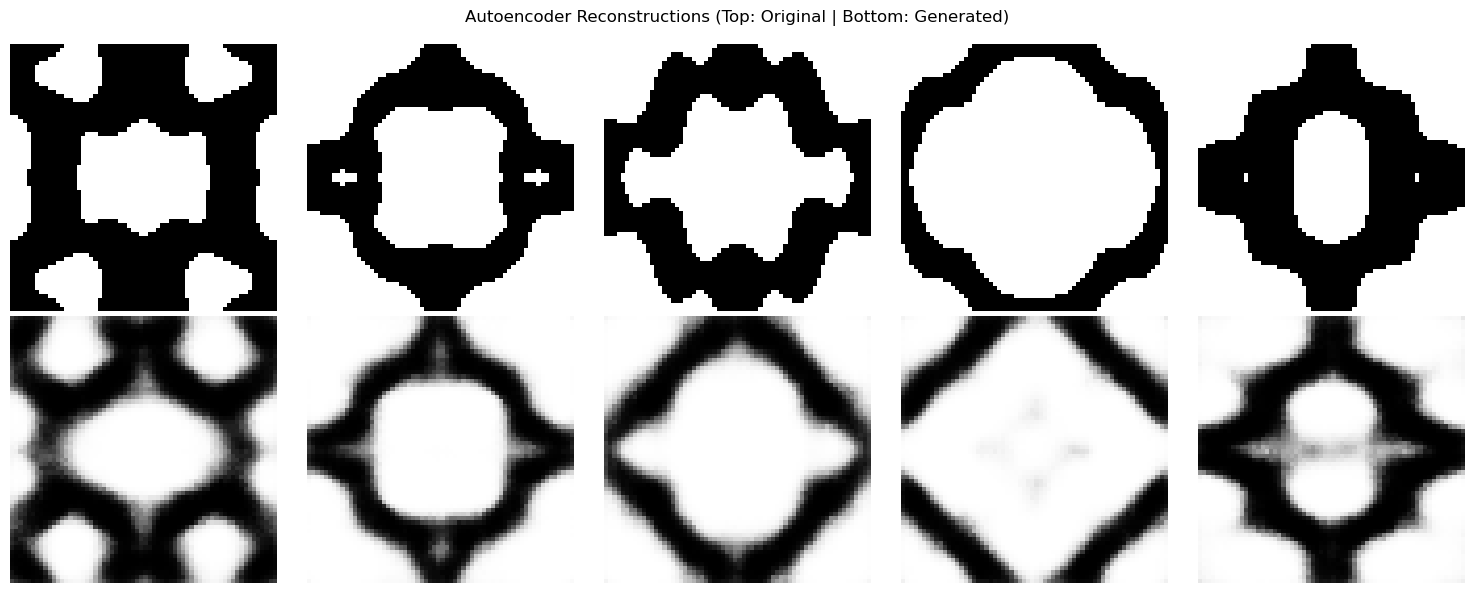

In [18]:
import matplotlib.pyplot as plt

def inspect_validation_batch(model, val_dataloader, device='cuda'):
    print("\n--- Running Inference on Validation Batch ---")
    
    # 1. Set model to evaluation mode (disables dropout, fixes batchnorm)
    model.eval()
    
    # 2. Grab exactly one batch of data
    images, strains, energies_true, stresses_true = next(iter(val_dataloader))
    
    # Move to GPU and ensure float32
    images = images.to(device, dtype=torch.float32)
    strains = strains.to(device, dtype=torch.float32)
    energies_true = energies_true.to(device, dtype=torch.float32)
    stresses_true = stresses_true.to(device, dtype=torch.float32)
    
    # 3. CRITICAL: We need gradients for the strain to calculate stress!
    strains.requires_grad_(True)
    
    # 4. Forward Pass
    W_pred, recon_images, mu, logvar = model(images, strains)
    
    # 5. Calculate Stress (Derivative of W_pred wrt strains)
    # Note: create_graph=False is fine here since we aren't backpropagating to update model weights
    S_pred = torch.autograd.grad(
        outputs=W_pred, 
        inputs=strains, 
        grad_outputs=torch.ones_like(W_pred), 
        create_graph=False
    )[0]
    
    # Move tensors back to CPU for printing and plotting
    W_pred = W_pred.detach().cpu().numpy()
    S_pred = S_pred.detach().cpu().numpy()
    energies_true = energies_true.cpu().numpy()
    stresses_true = stresses_true.cpu().numpy()
    
    # ==========================================
    # PRINT PHYSICAL VALUES (First 5 samples)
    # ==========================================
    np.set_printoptions(formatter={'float': '{: 0.4f}'.format})
    print(f"\n--- Energy Predictions (Joules) ---")
    i2p = [0,5,89,127,299]
    for i in range(5):
        print(f"Sample {i}: True = {energies_true[i,i2p,-1]} | Pred = {W_pred[i,i2p,-1][...,0]} | Diff = {abs(energies_true[i,i2p,-1] - W_pred[i,i2p,-1][...,0])}")
        
    print(f"\n--- Stress Predictions (S11, S22, S12) ---")
    for i in range(5):
        print(f"Sample {i}:")
        print(f"  True: {stresses_true[i,i2p,-1]}")
        print(f"  Pred: {S_pred[i,i2p,-1]}")
        print(f"  Diff: {abs(stresses_true[i,i2p,-1] - S_pred[i,i2p,-1])}")

    # ==========================================
    # PLOT RECONSTRUCTIONS (Autoencoder check)
    # ==========================================
    orig_imgs = images.detach().cpu().numpy()
    rec_imgs = recon_images.detach().cpu().numpy()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    plt.suptitle("Autoencoder Reconstructions (Top: Original | Bottom: Generated)")
    
    for i in range(5):
        # Original (Top row)
        axes[0, i].imshow(orig_imgs[i][0], cmap='Grays')
        axes[0, i].axis('off')
        # Reconstructed (Bottom row)
        axes[1, i].imshow(rec_imgs[i][0], cmap='Grays')
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
dv2 = DataLoader(val_subset,  batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
inspect_validation_batch(model, dv2, device=device)

In [ ]:
import torch
import gc

def hunt_fat_tensors(top_n=15):
    """Searches memory for the largest active PyTorch tensors and prints them."""
    print(f"\n--- HUNTING TOP {top_n} LARGEST TENSORS IN VRAM ---")
    
    tensors = []
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                # Calculate size in GB
                size_gb = obj.element_size() * obj.nelement() / (1024 ** 3)
                if size_gb > 0.01:  # Only care about tensors larger than 10MB
                    tensors.append((size_gb, obj.size(), obj.dtype, obj.device))
        except:
            pass # Some objects in gc are protected or restricted
            
    # Sort by size (descending)
    tensors.sort(key=lambda x: x[0], reverse=True)
    
    for i, (size, shape, dtype, device) in enumerate(tensors[:top_n]):
        print(f"#{i+1}: {size:.3f} GB | Shape: {list(shape)} | Type: {dtype} | On: {device}")
    print("--------------------------------------------------\n")

# Usage:
hunt_fat_tensors()